# Proyecto 1er Bimestre
**Integrantes: Danny Constante - Alexander Paillacho - Andrés Pérez**

**Prof. Iván Carrera — Recuperación de Información**  
**Fecha de entrega: 01 de junio de 2026**

### Celda 0: Instalación de Dependencias y Configuración del Entorno

En esta fase de inicialización, se preparan todas las bibliotecas de terceros necesarias para la ejecución del motor de búsqueda.
Las herramientas principales incluyen:
* **kagglehub:** Para la descarga automatizada del corpus de datos de Reuters desde los repositorios de Kaggle.
* **sentence-transformers:** Una librería del ecosistema Hugging Face esencial para la generación de *embeddings* (representaciones vectoriales densas) requeridos por el modelo de búsqueda semántica.
* **faiss-cpu:** (Facebook AI Similarity Search), una biblioteca escrita en C++ altamente optimizada para realizar búsquedas de similitud e indexación de vectores a gran escala de forma ultra-rápida.
* **scikit-learn:** Utilizada tanto para el cálculo del modelo TF-IDF como para la reducción de dimensionalidad (PCA) en el análisis visual.

In [3]:
# Ejecutar UNA sola vez al inicio del entorno (Kaggle / Colab / local)
!pip install -q kagglehub sentence-transformers faiss-cpu
!pip install -q scikit-learn pandas numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 89.9 MB/s eta 0:00:00


### Celda 1: Importación de Dependencias y Arquitectura del Entorno

En esta celda se inicializa el entorno de ejecución cargando en memoria todas las bibliotecas de terceros y módulos nativos que orquestarán el motor de búsqueda. Para mantener una arquitectura modular y eficiente, las dependencias se dividen en las siguientes categorías lógicas:

#### 1. Estructuras de Datos y Computación Científica
* **`pandas` y `numpy`:** Proveen el soporte fundamental para la manipulación matricial de los documentos y el manejo del *DataFrame* que consolida el corpus de noticias.
* **`collections` (`defaultdict`, `Counter`):** Estructuras de datos nativas de alta eficiencia. Se utilizan estrictamente para construir el **Índice Invertido** con una complejidad de tiempo óptima $O(N)$.
* **`math` y `re`:** Módulos para ejecutar cálculos probabilísticos (como el logaritmo en la fórmula de BM25) y expresiones regulares para la limpieza y análisis de los fragmentos de texto.

#### 2. Modelado Léxico (Estadístico)
* **`sklearn.feature_extraction.text.TfidfVectorizer`:** Motor principal para construir la matriz de representación dispersa (Bolsa de Palabras) aplicando el suavizado logarítmico y la penalización de frecuencia.
* **`sklearn.metrics.pairwise.cosine_similarity`:** Calcula algebraicamente el ángulo (distancia espacial) entre el vector disperso de la consulta y los vectores de los documentos para el modelo TF-IDF.

#### 3. Modelado Semántico (Aprendizaje Profundo)
* **`sentence_transformers` (`SentenceTransformer`):** Interfaz central para cargar la red neuronal preentrenada (ej. *all-mpnet-base-v2*) responsable de leer el texto crudo y codificar su significado en vectores densos.
* **`faiss`:** Librería desarrollada por Meta AI, especializada en la indexación hiper-rápida y el cálculo del producto interno sobre espacios vectoriales continuos de alta dimensionalidad.

#### 4. Utilidades de Interfaz y Visualización
* **`matplotlib.pyplot`:** Herramienta de graficación geométrica para el renderizado del Análisis de Componentes Principales (PCA) y el mapeo de dispersión espacial.
* **`IPython.display` (`display`, `clear_output`):** Permiten renderizar los DataFrames en formato tabular limpio directamente en el entorno Jupyter, y limpiar la pantalla asíncronamente para simular un Buscador CLI fluido sin desbordar el navegador.
* **`tqdm`:** Proporciona barras de progreso en tiempo real para auditar el costo temporal durante la vectorización o la construcción de índices masivos.

In [17]:
import os, math, warnings
import pandas as pd
import numpy as np
import re
import math
import time
import importlib
import faiss
from IPython.display import display, clear_output
from collections import defaultdict, Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
import faiss

warnings.filterwarnings('ignore')
print("Importaciones completadas")

Importaciones completadas


### Celda 2: Ingesta Dinámica y Estructuración del Corpus de Reuters

En esta fase se orquesta la ingesta de la base de datos documental. Dado que el dataset de Reuters se encuentra fragmentado en múltiples archivos CSV (representando particiones históricas como *ModApte*, *ModHayes*, *ModLewis*), el sistema implementa un pipeline de carga dinámica con las siguientes características:

1. **Descarga Automatizada:** Utiliza la API de Kaggle (`kagglehub`) para garantizar la reproducibilidad del entorno sin requerir la gestión manual de archivos.
2. **Detección Dinámica de Esquemas (Heurística):** Dado que diferentes archivos CSV pueden tener distintas convenciones de nombres para sus columnas, el sistema busca coincidencia de nombres estándar ('text', 'body'). Si falla, aplica una métrica heurística: asume que la columna de texto es aquella que contiene la mayor longitud promedio de caracteres.
3. **Trazabilidad (Procedencia de Datos):** Se inyecta una columna sintética llamada `csv_origen` para mantener la trazabilidad exacta de dónde provino cada documento, algo vital al unificar el corpus.
4. **Generación de Llaves Primarias:** Se genera un `doc_id` unívoco combinando el prefijo del archivo de origen y el índice iterativo para evitar colisiones en el índice invertido.
5. **Sanitización Inicial:** Se descartan documentos nulos o excesivamente cortos (menores a 30 caracteres) para reducir el ruido estadístico antes del procesamiento del lenguaje natural.

In [5]:
import kagglehub

DATASET_ID = "thedevastator/uncovering-financial-insights-with-the-reuters-2"

# 1. Descarga y configuración del entorno de datos
print("Descargando dataset de Reuters desde Kaggle...")
ruta_carpeta = kagglehub.dataset_download(DATASET_ID)
print(f"Directorio de ingesta: {ruta_carpeta}\n")

# Exploración y listado de archivos CSV en el directorio descargado
archivos_csv = sorted([
    f for f in os.listdir(ruta_carpeta)
    if f.endswith('.csv')
])

print(f"Archivos CSV detectados para procesamiento ({len(archivos_csv)}):")
for a in archivos_csv:
    print(f"   • {a}")

# Diccionario para almacenar temporalmente los DataFrames aislados
corpus_por_csv = {}

# Vocabulario de posibles nombres para la columna principal de texto
CANDIDATAS_TEXTO = ['text', 'article_text', 'body', 'content', 'description']

print("\nIniciando pipeline de carga y sanitización...")
for nombre_csv in archivos_csv:
    ruta_csv = os.path.join(ruta_carpeta, nombre_csv)
    try:
        # Carga tolerante a fallos: omite líneas con mal formato estructural
        df_temp = pd.read_csv(ruta_csv, on_bad_lines='skip')

        # --- Heurística de Detección Dinámica de Columnas ---
        # Intento 1: Búsqueda por coincidencia de diccionario
        col_texto = next((c for c in CANDIDATAS_TEXTO if c in df_temp.columns), None)

        # Intento 2: Inferencia basada en longitud de caracteres
        if col_texto is None:
            cols_str = df_temp.select_dtypes(include='object').columns
            if len(cols_str) == 0:
                print(f"   ⚠️  {nombre_csv} — Excluido: Ausencia de datos textuales.")
                continue
            # Selecciona la columna cuya longitud de string promedio sea la mayor
            col_texto = df_temp[cols_str].apply(lambda c: c.str.len().mean()).idxmax()

        # Detección de columna de metadatos (Título)
        col_titulo = next((c for c in ['title','headline','subject'] if c in df_temp.columns), None)

        # Reestructuración y Estandarización del DataFrame
        df_csv = df_temp[[col_texto]].copy()
        df_csv.columns = ['texto']
        df_csv['titulo'] = df_temp[col_titulo] if col_titulo else ''

        # Etiquetado de trazabilidad (Procedencia del dato)
        df_csv['csv_origen'] = nombre_csv

        # --- Sanitización de Ruido ---
        df_csv = df_csv.dropna(subset=['texto'])
        # Se descartan fragmentos residuales (< 30 caracteres)
        df_csv = df_csv[df_csv['texto'].str.strip().str.len() >= 30]
        df_csv = df_csv.reset_index(drop=True)

        # Generación de Llave Primaria (doc_id)
        # Se previene colisión de IDs concatenando el origen y el índice
        prefijo = nombre_csv.replace('.csv', '').replace(' ', '_')
        df_csv['doc_id'] = [f"{prefijo}_{i}" for i in df_csv.index]

        corpus_por_csv[nombre_csv] = df_csv
        print(f"   {nombre_csv:<35} → {len(df_csv):>5} documentos  |  col_texto='{col_texto}'")

    except Exception as e:
        print(f"   ❌ {nombre_csv} — Error crítico en carga: {e}")

# Concatenación vertical de todas las particiones en un único espacio de memoria
df = pd.concat(corpus_por_csv.values(), ignore_index=True)

print(f"\n{'='*55}")
print(f"  RESUMEN DE INGESTA GLOBAL")
print(f"  Corpus Unificado : {len(df):,} documentos")
print(f"  Particiones (CSV): {len(corpus_por_csv)}")
print(f"  Distribución de procedencia:")
for csv_name, conteo in df['csv_origen'].value_counts().items():
    print(f"    {csv_name:<35} {conteo:>6} docs")
print(f"{'='*55}")

# Muestra exploratoria de la estructura final
display(df[['doc_id', 'csv_origen', 'titulo', 'texto']].head(4))

Descargando dataset de Reuters desde Kaggle...


100%|██████████| 17.8M/17.8M [00:02<00:00, 8.56MB/s]

Extracting files...


Directorio de ingesta: /root/.cache/kagglehub/datasets/thedevastator/uncovering-financial-insights-with-the-reuters-2/versions/2

Archivos CSV detectados para procesamiento (8):
   • ModApte_test.csv
   • ModApte_train.csv
   • ModApte_unused.csv
   • ModHayes_test.csv
   • ModHayes_train.csv
   • ModLewis_test.csv
   • ModLewis_train.csv
   • ModLewis_unused.csv

Iniciando pipeline de carga y sanitización...
   ModApte_test.csv                    →  3023 documentos  |  col_texto='text'
   ModApte_train.csv                   →  8816 documentos  |  col_texto='text'
   ModApte_unused.csv                  →   722 documentos  |  col_texto='text'
   ModHayes_test.csv                   →   722 documentos  |  col_texto='text'
   ModHayes_train.csv                  → 19055 documentos  |  col_texto='text'
   ModLewis_test.csv                   →  5486 documentos  |  col_texto='text'
   ModLewis_train.csv                  → 12531 documentos  |  col_texto='text'
   ModLewis_unused.csv            

,doc_id,csv_origen,titulo,texto
0,ModApte_test_0,ModApte_test.csv,ASIAN EXPORTERS FEAR DAMAGE FROM U.S.-JAPAN RIFT,Mounting trade friction between the\nU.S. And ...
1,ModApte_test_1,ModApte_test.csv,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRAIN STOCKS,A survey of 19 provinces and seven cities\nsho...
2,ModApte_test_2,ModApte_test.csv,JAPAN TO REVISE LONG-TERM ENERGY DEMAND DOWNWARDS,The Ministry of International Trade and\nIndus...
3,ModApte_test_3,ModApte_test.csv,THAI TRADE DEFICIT WIDENS IN FIRST QUARTER,Thailand's trade deficit widened to 4.5\nbilli...


### Celda 3: Módulo de Preprocesamiento Lingüístico Bifurcado (`limpieza.py`)

El procesamiento de lenguaje natural (NLP) no es un enfoque de "talla única". Los modelos estadísticos clásicos y las redes neuronales profundas "leen" el texto de maneras fundamentalmente opuestas. Para maximizar el rendimiento de ambos ecosistemas, se implementa una **Arquitectura de Pipeline Bifurcado**.



#### 1. Gestión de Stopwords (Ruido de Dominio)
Además de las palabras vacías estándar del inglés (conjunciones, artículos), se define un set heurístico de **Stopwords Financieras**. En el corpus de Reuters, términos como *"said"*, *"mln"* (millones), *"pct"* (porcentaje) o los meses del año aparecen en casi todos los documentos. Para los modelos léxicos, estas palabras actúan como ruido estadístico de alta frecuencia que diluye el peso de los términos verdaderamente discriminativos.

#### 2. Pipeline Semántico (Para Sentence-Transformers)
Las arquitecturas basadas en *Atención* (Transformers) dependen de la sintaxis estructural para calcular el contexto. Si se eliminan las preposiciones o se reducen los verbos a su raíz, el modelo pierde su capacidad de inferir significado complejo.
* **Estrategia:** Limpieza puramente superficial. Se erradican artefactos de codificación (caracteres de control nulos, etiquetas HTML remanentes y URLs) preservando intacta la gramática, conjugación y capitalización original.

#### 3. Pipeline Léxico (Para BM25, TF-IDF y Jaccard)
Los modelos estadísticos ("Bolsa de Palabras") son algoritmos de coincidencia exacta. Matemáticamente ignoran que "price" y "prices" comparten semántica.
* **Estrategia:** Reducción dimensional del vocabulario mediante **Lematización**. Utilizando `WordNetLemmatizer` de NLTK, se transforman los plurales a singulares y los verbos conjugados a su forma base. Este proceso, combinado con la eliminación exhaustiva de signos de puntuación y *stopwords*, garantiza que la intersección de conjuntos y las matrices de frecuencia operen con la máxima densidad y precisión cruzada posible.

In [6]:
%%writefile limpieza.py
# ARQUITECTURA BIFURCADA
# Pipeline Léxico: Normalización → Tokenización → Stopwords → Lematización
# Pipeline Semántico: Sanitización estructural (Preserva sintaxis)
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 1. Inicialización y descarga de modelos morfológicos y léxicos (NLTK)
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)  # Motor de relaciones semánticas (Lematización)
nltk.download('omw-1.4',   quiet=True)  # Open Multilingual Wordnet (Dependencia)

# 2. Construcción del filtro de ruido (Stopwords)
NLTK_SW = set(stopwords.words('english'))

# Filtro de alta frecuencia específico del corpus de Reuters (Finanzas/Noticias)
FINANCIAL_SW = {
    "said","reuters","new","one","two","three","four","five","six",
    "seven","eight","nine","ten","pct","mln","bln","dlrs","dlr",
    "cents","billion","million","inc","corp","ltd","co",
    "january","february","march","april","may","june","july",
    "august","september","october","november","december"
}

# Fusión de conjuntos O(1) para búsquedas de exclusión ultrarrápidas
ALL_SW = NLTK_SW | FINANCIAL_SW

# Instanciación del motor lematizador
lemmatizer = WordNetLemmatizer()


# PIPELINE 1: MODELADO SEMÁNTICO (Redes Neuronales / Embeddings)
def limpiar_para_semantico(texto: str) -> str:
    """
    Sanitización pasiva. Elimina artefactos de extracción de datos,
    pero preserva intactos los conectores lógicos, tiempos verbales
    y puntuación requeridos por los mecanismos de Auto-Atención.
    """
    if not isinstance(texto, str):
        return ""

    texto = re.sub(r'<[^>]+>', ' ', texto)           # Remoción de nodos HTML
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)  # Remoción de hipervínculos
    texto = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', texto) # Purga de caracteres de control ASCII
    texto = re.sub(r'\s+', ' ', texto).strip()       # Normalización de espacios en blanco

    return texto

# PIPELINE 2: MODELADO LÉXICO (Modelos Estadísticos Clásicos)
def normalizar_lexico(texto: str) -> str:
    """
    Aplanamiento morfológico inicial: minúsculas absolutas y
    destrucción de cualquier carácter que no sea alfabético.
    """
    if not isinstance(texto, str):
        return ""

    texto = texto.lower()
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = re.sub(r'https?://\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'[^a-z\s]', ' ', texto)          # Filtro estricto: Solo a-z y espacios
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

def preprocesar_lista_lexico(texto: str) -> list:
    """
    Genera el vector de características base (tokens) para el Índice Invertido.
    Aplica reducción dimensional (Lematización) para colapsar variaciones
    morfológicas (ej. prices -> price, running -> run) en un solo token matemático.
    """
    tokens = word_tokenize(normalizar_lexico(texto))
    tokens_limpios = []

    for t in tokens:
        # Filtramos ruido: stopwords y palabras residuales muy cortas
        if t not in ALL_SW and len(t) > 2:
            # Lematización: Extracción de la raíz canónica
            lemma = lemmatizer.lemmatize(t)
            tokens_limpios.append(lemma)

    return tokens_limpios

def limpiar_para_lexicos_str(texto: str) -> str:
    """
    Adaptador de salida en formato de cadena (String).
    Requerido por interfaces que vectorizan internamente como TfidfVectorizer.
    """
    return ' '.join(preprocesar_lista_lexico(texto))

Writing limpieza.py


### Celda 3.1: Ejecución del Pipeline de Transformación de Datos (Bifurcación en Memoria)

Una vez definida la arquitectura de procesamiento en el módulo `limpieza.py`, esta celda se encarga de la materialización de la **Bifurcación de Datos** sobre todo el corpus documental (más de 51,000 registros).

Para evitar cuellos de botella computacionales durante la fase de búsqueda interactiva (CLI), la costosa operación de lematización y filtrado morfológico se ejecuta en *batch* (por lotes) una única vez durante el ciclo de vida del sistema, almacenando los resultados en nuevas estructuras espaciales dentro del *DataFrame* principal de Pandas.

[Image of data preprocessing pipeline natural language processing]

Se generan tres representaciones textuales paralelas para satisfacer los requerimientos matemáticos exactos de cada modelo:

1. **Columna `texto_semantico`:** Almacena el texto con sanitización pasiva. Es el insumo exclusivo para la fase de *Word Embeddings* mediante *Sentence-Transformers*, garantizando que la red neuronal reciba la sintaxis y los conectores lógicos (preposiciones, pronombres) necesarios para el mecanismo de auto-atención (*Self-Attention*).
2. **Columna `texto_lexico_str`:** Contiene una cadena plana (*string*) de palabras lematizadas y purgadas de ruido (*stopwords*). Es el formato de entrada estandarizado que exige la librería `scikit-learn` para el cálculo matricial de `TfidfVectorizer`.
3. **Columna `tokens_lexicos`:** Almacena una lista de elementos iterables (los lemas puros). Es la estructura de datos ideal, con complejidad de tiempo $O(1)$ por token, para la construcción del diccionario multidimensional del Índice Invertido (utilizado por BM25 y Jaccard).

In [7]:
# APLICACIÓN DE LA BIFURCACIÓN DE DATOS SOBRE EL CORPUS GLOBAL
# Transformación paralela: Representación Neuronal vs Representación Léxica
import limpieza

# Recarga dinámica del módulo para asegurar la última versión en Jupyter
importlib.reload(limpieza)
from limpieza import limpiar_para_semantico, limpiar_para_lexicos_str, preprocesar_lista_lexico

print(f"Iniciando procesamiento de lenguaje natural en {len(df):,} documentos...")
print(" (El análisis morfológico y lematización de NLTK requiere poder de cómputo. Espere...)")

# Definición de la columna fuente
columna_origen = 'texto'

# 1. GENERACIÓN DEL ESPACIO SEMÁNTICO (Redes Neuronales)
# Preserva gramática, conectores y verbos para la inferencia de contexto.
df['texto_semantico'] = df[columna_origen].apply(limpiar_para_semantico)

# 2. GENERACIÓN DEL ESPACIO LÉXICO (Modelos Estadísticos / Bolsa de Palabras)
# Formato Cadena (String): Requerido para la matriz de compresión TfidfVectorizer
df['texto_lexico_str'] = df[columna_origen].apply(limpiar_para_lexicos_str)

# Formato Lista (Tokens): Requerido para mapeo rápido en el Índice Invertido (BM25/Jaccard)
df['tokens_lexicos']   = df[columna_origen].apply(preprocesar_lista_lexico)

# 3. AUDITORÍA DE TRANSFORMACIÓN (Verificación de Calidad)
ej = df.iloc[0]
print(f"\nTransformación del corpus completada exitosamente.")
print(f"   Muestra aleatoria — Documento ID: '{ej['doc_id']}' (Fuente: {ej['csv_origen']})")
print(f"   ▶ Input Semántico (FAISS)   : {ej['texto_semantico'][:90]}...")
print(f"   ▶ Input Léxico    (BM25/TF) : {ej['tokens_lexicos'][:10]}")

Iniciando procesamiento de lenguaje natural en 51,077 documentos...
 (El análisis morfológico y lematización de NLTK requiere poder de cómputo. Espere...)

Transformación del corpus completada exitosamente.
   Muestra aleatoria — Documento ID: 'ModApte_test_0' (Fuente: ModApte_test.csv)
   ▶ Input Semántico (FAISS)   : Mounting trade friction between theU.S. And Japan has raised fears among many of Asia's ex...
   ▶ Input Léxico    (BM25/TF) : ['mounting', 'trade', 'friction', 'japan', 'raised', 'fear', 'among', 'many', 'asia', 'exporting']


### Celda 4: Construcción del Índice Invertido y Estructuras Estáticas de Metadatos

Para que un motor de búsqueda probabilístico o basado en conjuntos (como BM25 o Jaccard) sea operativamente viable en entornos de producción, es computacionalmente prohibitivo escanear secuencialmente 51,000 documentos por cada consulta de usuario ($O(N)$). Para resolver esto, la arquitectura se invierte construyendo un **Índice Invertido**.

[Image of inverted index data structure in information retrieval]

#### 1. El Índice Invertido (Matriz Dispersa de Términos)
Es la estructura de datos fundamental en Recuperación de Información Clásica.
* **Estructura:** Se implementa como un diccionario de diccionarios (`{ término: { doc_id: frecuencia } }`).
* **Lógica:** Mapea cada término único del vocabulario léxico (lematizado) hacia sus *Posting Lists* (la lista de documentos donde aparece dicho término, junto con su Frecuencia de Término o *TF* local). Al buscar la palabra "petrol", el motor no lee los 51,000 documentos, sino que accede en tiempo $O(1)$ a la llave "petrol" y recupera únicamente el subconjunto de documentos relevantes.

#### 2. Diccionario de Metadatos (Acceso $O(1)$)
Separar el texto original del índice matemático es una buena práctica de ingeniería para optimizar la memoria RAM

In [8]:
# CONSTRUCCIÓN DEL ÍNDICE INVERTIDO Y PRE-CÁLCULO DE METADATOS
# Optimización de estructuras de datos para búsquedas en tiempo O(1)
def construir_indice_invertido(df: pd.DataFrame) -> dict:
    """
    Construye la estructura de mapeo: Término -> Posting Lists (doc_id, TF_local).
    Se alimenta estrictamente del pipeline léxico (lemas).
    """
    indice = defaultdict(dict)

    for _, fila in tqdm(df.iterrows(), total=len(df), desc="Indexando vocabulario léxico"):
        doc_id = fila['doc_id']

        # Counter() extrae la frecuencia exacta de cada lema en el documento (Term Frequency - TF)
        for termino, freq in Counter(fila['tokens_lexicos']).items():
            indice[termino][doc_id] = freq

    return dict(indice)

def construir_metadatos(df: pd.DataFrame) -> dict:
    """
    Construye un diccionario de acceso ultra-rápido O(1) para evitar
    operaciones costosas sobre el DataFrame durante la ejecución de búsquedas.
    """
    meta = {}

    for _, fila in df.iterrows():
        meta[fila['doc_id']] = {
            # Atributos Matemáticos (Requeridos por BM25 y Jaccard)
            'longitud'       : len(fila['tokens_lexicos']),
            'tokens'         : fila['tokens_lexicos'],

            # Atributos de Presentación (Requeridos por la Interfaz de Usuario)
            'titulo'         : str(fila.get('titulo', '')),
            'texto_original' : str(fila['texto']),
            'csv_origen'     : fila['csv_origen'],          # Trazabilidad
        }

    return meta

# EJECUCIÓN Y CACHEO DE VARIABLES GLOBALES
print("Inicializando construcción de estructuras en memoria...")
indice    = construir_indice_invertido(df)
metadatos = construir_metadatos(df)

# Variables estáticas globales obligatorias para normalización probabilística (BM25)
LONGITUD_PROMEDIO = np.mean([v['longitud'] for v in metadatos.values()])
TOTAL_DOCS        = len(df)

# Auditoría del proceso
print(f"\nIndexación completada:")
print(f"  • Vocabulario Léxico (Lemas) : {len(indice):,} términos únicos")
print(f"  • Total de Documentos        : {TOTAL_DOCS:,}")
print(f"  • Longitud media documental  : {LONGITUD_PROMEDIO:.2f} tokens")

Inicializando construcción de estructuras en memoria...


Indexando vocabulario léxico: 100%|██████████| 51077/51077 [00:03<00:00, 13125.95it/s]



Indexación completada:
  • Vocabulario Léxico (Lemas) : 35,609 términos únicos
  • Total de Documentos        : 51,077
  • Longitud media documental  : 69.34 tokens


---
### Celda 5.1: Modelo de Recuperación 1 — Similitud de Jaccard

#### ¿Cómo entiende las búsquedas este modelo? (Explicación sencilla)
Imagina que la frase que escribes en el buscador es la **"Lista A"** de palabras, y cada noticia en el sistema es una **"Lista B"**. Para saber si una noticia es relevante, el algoritmo de Jaccard compara ambas listas y se hace dos preguntas muy simples:

1. **¿Qué tenemos en común? (Intersección):** Cuenta cuántas palabras exactas aparecen en ambas listas.
2. **¿Cuánto hay en total? (Unión):** Cuenta todas las palabras únicas juntando ambas listas.

La puntuación final es simplemente dividir lo que tienen en común entre el total. Por ejemplo, si buscaste 2 palabras ("precio", "petróleo") y una noticia tiene esas 2 palabras junto con otras 8 distintas (10 palabras en total), tu nivel de similitud es 2/10 = 20%.

**El punto débil del modelo:** Es binario y "ciego" a la importancia. Para Jaccard, acertar una palabra rarísima vale matemáticamente lo mismo que acertar una palabra común. Además, no le importa si la palabra "petróleo" aparece 1 vez o 50 veces en la noticia; para este algoritmo, si la palabra está presente, cuenta como un "1", y si no, como un "0".

#### Explicación Técnica y Optimización
A nivel algorítmico, este modelo asume el texto como conjuntos (sets) y aplica la métrica: $J(A,B) = \frac{|A \cap B|}{|A \cup B|}$.

Dado que comparar conjuntos contra 51,000 documentos colapsaría el rendimiento computacional, el código implementa una optimización crítica: **Extracción Previa de Candidatos**. Antes de calcular divisiones, el sistema interroga al Índice Invertido para aislar *únicamente* los documentos que comparten al menos un token con la consulta, reduciendo las operaciones de decenas de miles a solo unas cuantas docenas.

In [9]:
# MODELO 1 — SIMILITUD DE JACCARD (Enfoque de Conjuntos Binarios)
# Fórmula: Jaccard(A,B) = |A∩B| / |A∪B|
from limpieza import preprocesar_lista_lexico

def jaccard_search(consulta: str, indice: dict, metadatos: dict, top_k: int = 10) -> list:
    """
    Motor de búsqueda basado en intersección pura de conjuntos.
    Ignora la frecuencia de los términos (TF) y la rareza global (IDF).
    """
    # 1. Transformación Léxica: Convertimos la consulta en un conjunto de lemas puros
    tokens_consulta = set(preprocesar_lista_lexico(consulta))

    if not tokens_consulta:
        return []

    # 2. Extracción Óptima de Candidatos O(1)
    # Filtramos el universo de documentos. Solo evaluamos aquellos que
    # cruzan con al menos un término de la búsqueda a través del Índice Invertido.
    docs_candidatos = set()
    for t in tokens_consulta:
        if t in indice:
            docs_candidatos.update(indice[t].keys())

    # 3. Evaluación Métrica (Intersección sobre Unión)
    scores = {}
    for doc_id in docs_candidatos:
        # Recuperamos el set de tokens lematizados precalculado en la Celda 4
        tokens_doc = set(metadatos[doc_id]['tokens'])

        # Matemática de conjuntos
        interseccion = len(tokens_consulta & tokens_doc)
        union        = len(tokens_consulta | tokens_doc)

        # Asignación de score (previniendo división por cero)
        if union > 0:
            scores[doc_id] = interseccion / union

    # 4. Ordenamiento y Truncado (Top K)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

print(" Modelo 1: jaccard_search definida e integrada con pipeline léxico.")

 Modelo 1: jaccard_search definida e integrada con pipeline léxico.


### Celda 5.2: Modelo de Recuperación 2 — TF-IDF y Similitud Coseno

#### ¿Cómo entiende las búsquedas este modelo? (Explicación sencilla)
A diferencia de Jaccard, que cuenta palabras a ciegas, **TF-IDF** actúa como un bibliotecario inteligente que sabe qué palabras importan y cuáles no, utilizando dos reglas de oro:
1. **Regla de la repetición (TF):** Si una noticia repite muchas veces la palabra "petróleo", probablemente trate sobre petróleo. (Premia la repetición local).
2. **Regla de la rareza (IDF):** Si buscas la palabra "empresa", te darás cuenta de que casi todas las noticias financieras la tienen. Como no ayuda a distinguir una noticia de otra, el modelo le quita valor. Pero si buscas "Triton", como aparece en muy pocos artículos, el modelo le asigna un valor multiplicador gigantesco.



**La Similitud Coseno (El Ángulo):** Una vez que el modelo ha puntuado las palabras, convierte cada noticia en una flecha geométrica (vector) en un espacio invisible. Tu búsqueda también se convierte en una flecha. En lugar de medir qué tan "lejos" están los puntos, el algoritmo mide el **ángulo** entre las flechas. Si tu flecha y la flecha de la noticia apuntan exactamente en la misma dirección (ángulo de 0 grados = coseno de 1), significa que comparten el mismo perfil de palabras clave importantes.

#### Explicación Técnica y Optimización
Este algoritmo representa el paradigma del **Modelo de Espacio Vectorial (VSM)**.
* **Matriz Dispersa:** Convierte todo el corpus en una matriz multidimensional masiva donde las filas son documentos (51,000) y las columnas son cada lema único del vocabulario (decenas de miles).
* **Suavizado Logarítmico (`sublinear_tf`):** Para evitar que un artículo larguísimo que repite "petróleo" 100 veces derrote injustamente a un artículo corto que lo dice 5 veces, se aplica $1 + \log(TF)$. Esto "satura" el valor matemático, haciendo que la repetición masiva tenga rendimientos decrecientes.
* **Reducción de Dimensionalidad (Min/Max DF):** Se ignoran las palabras que aparecen en el 95% del corpus o en menos de 2 documentos, podando la matriz para ahorrar memoria RAM y eliminar ruido estadístico.

In [10]:
# MODELO 2 — TF-IDF + SIMILITUD COSENO (Espacio Vectorial)
# Term Frequency - Inverse Document Frequency
from limpieza import limpiar_para_lexicos_str

print("Construyendo matriz TF-IDF sobre el corpus unificado...")

# 1. Configuración del Vectorizador (Ingeniería de Características)
vectorizer_tfidf = TfidfVectorizer(
    # Pasamos una función identidad porque nuestro texto YA fue preprocesado
    # y lematizado exhaustivamente en la Celda 3.
    preprocessor=lambda x: x,
    tokenizer=str.split,

    # Suavizado matemático: Reemplaza TF puro con 1 + log(TF)
    sublinear_tf=True,

    # Poda del vocabulario (Reducción de ruido y ahorro de RAM)
    min_df=2,            # Descarta "hapax legomena" (palabras que aparecen 1 sola vez)
    max_df=0.95,         # Descarta stopwords residuales (palabras en >95% de los docs)
)

# 2. Entrenamiento e Ingesta de Datos (Vectorización)
# Ingestamos exclusivamente el pipeline léxico (String plano con lemas)
corpus_limpio = df['texto_lexico_str'].tolist()
matriz_tfidf  = vectorizer_tfidf.fit_transform(corpus_limpio)
idx_a_docid   = df['doc_id'].tolist()

print(f"Matriz dispersa TF-IDF generada: {matriz_tfidf.shape} (Docs × Dimensiones/Lemas)")

# MOTOR DE BÚSQUEDA TF-IDF
def tfidf_search(consulta: str, vectorizer, matriz_tfidf,
                 idx_a_docid: list, top_k: int = 10) -> list:
    """
    Proyecta la consulta del usuario en el mismo hiperespacio multidimensional
    que los documentos y calcula el cruce angular (Similitud Coseno).
    """

    # A. Aplanamiento morfológico: Lematizamos la consulta del usuario
    consulta_limpia = limpiar_para_lexicos_str(consulta)

    # B. Vectorización: Convertimos la consulta en un vector disperso (1 x N_dimensiones)
    vector_consulta = vectorizer.transform([consulta_limpia])

    # C. Álgebra lineal: Producto punto normalizado (Similitud Coseno)
    # Compara la consulta (1xN) contra TODA la matriz documental (51000xN) de un golpe
    scores = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

    # D. Ordenamiento (argsort) de mayor a menor extrayendo el Top-K
    top_indices = scores.argsort()[-top_k:][::-1]

    # Retornamos tuplas de (ID_Documento, Score)
    return [(idx_a_docid[i], float(scores[i]))
            for i in top_indices if scores[i] > 0]

print(" Modelo 2: tfidf_search definida e integrada con pipeline léxico.")

Construyendo matriz TF-IDF sobre el corpus unificado...
Matriz dispersa TF-IDF generada: (51077, 35183) (Docs × Dimensiones/Lemas)
 Modelo 2: tfidf_search definida e integrada con pipeline léxico.


### Celda 5.3: Modelo de Recuperación 3 — Okapi BM25 (El Estándar de la Industria)

#### ¿Cómo entiende las búsquedas este modelo? (Explicación sencilla)
Si TF-IDF es un bibliotecario inteligente, **BM25** es un bibliotecario experto que corrige dos grandes injusticias que ocurren al buscar documentos:

1. **El Problema del "Spam" (Saturación de Frecuencia):** En el modelo TF-IDF normal, si un artículo repite la palabra "petróleo" 100 veces, el sistema cree que es 100 veces más relevante. BM25 introduce un "límite de velocidad" (el parámetro $k_1$). Al principio, cada vez que aparece la palabra suma muchos puntos, pero después de unas cuantas repeticiones, el algoritmo dice: *"Ya entendí que hablas de petróleo, repetirlo más no te hará ganar más puntos"*. Esto evita que artículos repetitivos ganen posiciones injustamente.

[Image of Okapi BM25 term frequency saturation curve compared to TF-IDF]

2. **El Problema del Artículo Gigante (Normalización por Longitud):** Un libro de 500 páginas tiene una ventaja injusta sobre una noticia corta de 1 página, simplemente porque, por pura probabilidad estadística, el libro contendrá más veces tus palabras clave. BM25 arregla esto calculando la **longitud promedio** de todas las noticias. Si un artículo es más largo que el promedio, se le aplica un castigo (una pequeña penalización). Si es más corto y va directo al grano, se le da un premio. Esto es controlado por el parámetro $b$.

#### Explicación Técnica y Optimización
BM25 es un modelo de recuperación **probabilístico**. Su eficiencia algorítmica en este código radica en dos decisiones de ingeniería:
* **Cálculo Previo del IDF:** Se calcula el peso probabilístico inverso (`idf_bm25`) de los decenas de miles de términos del vocabulario una sola vez en memoria, en lugar de recalcularlo en cada búsqueda.
* **Recorrido Invertido $O(n)$:** Durante la búsqueda, el algoritmo jamás itera sobre el corpus completo. Itera exclusivamente sobre los tokens que ingresó el usuario, y accede al diccionario del Índice Invertido (`indice[termino]`) para sumar el *score* únicamente a los `doc_id` que contienen dicho término, logrando tiempos de respuesta de milisegundos.

In [11]:
# MODELO 3 — OKAPI BM25 (Modelo Probabilístico)
# score(q,d) = Σ IDF(t) · TF_sat(t,d) con normalización de longitud
from collections import defaultdict
from limpieza import preprocesar_lista_lexico

# Hiperparámetros empíricos estándar de la literatura académica para BM25
BM25_K1 = 1.5   # k1: Límite de saturación. Controla el límite asintótico de la frecuencia del término.
BM25_B  = 0.75  # b:  Peso de normalización. Define qué tanto castigar a los documentos muy largos.

def calcular_idf_bm25(indice: dict, total_docs: int) -> dict:
    """
    Pre-calcula el Inverse Document Frequency (IDF) probabilístico para todo el vocabulario.
    Se ejecuta de forma estática antes de habilitar el buscador para maximizar el rendimiento.
    """
    idf = {}
    for termino, postings in indice.items():
        # df_t (Document Frequency): En cuántos documentos existe esta palabra
        df_t = len(postings)

        # Fórmula matemática del IDF probabilístico de Robertson-Spärck Jones.
        # Asigna un multiplicador alto a términos raros y uno bajo a términos comunes.
        idf[termino] = math.log((total_docs - df_t + 0.5) / (df_t + 0.5) + 1)

    return idf

def bm25_search(consulta: str, indice: dict, metadatos: dict,
                idf_bm25: dict, longitud_promedio: float, total_docs: int,
                k1: float = BM25_K1, b: float = BM25_B,
                top_k: int = 10) -> list:
    """
    Motor de búsqueda iterando sobre el Índice Invertido con cálculo de saturación y longitud.
    """
    # 1. Transformación Morfológica: Convertimos la consulta en lemas
    tokens_consulta = preprocesar_lista_lexico(consulta)

    if not tokens_consulta:
        return []

    scores = defaultdict(float)

    # 2. Interrogamos al índice SOLO por las palabras clave del usuario
    for termino in tokens_consulta:
        # Si la palabra es desconocida para el corpus, se ignora
        if termino not in indice:
            continue

        # Obtenemos el peso estático de la palabra
        idf_t = idf_bm25.get(termino, 0.0)

        # 3. Iteramos exclusivamente sobre los documentos candidatos (Posting List)
        for doc_id, tf_td in indice[termino].items():

            # Recuperamos la longitud real del documento en tiempo O(1)
            ld = metadatos[doc_id]['longitud']

            # --- FACTOR DE NORMALIZACIÓN (b) ---
            # norm > 1 si el doc es más largo que el promedio (Castigo)
            # norm < 1 si el doc es más corto que el promedio (Premio)
            norm = 1 - b + b * (ld / longitud_promedio)

            # --- FACTOR DE SATURACIÓN (k1) ---
            # El crecimiento del score por repetir la palabra se frena asintóticamente
            tf_s = (tf_td * (k1 + 1)) / (tf_td + k1 * norm)

            # Acumulamos el score total para este documento
            scores[doc_id] += idf_t * tf_s

    # 4. Ordenamiento inverso para devolver el Top-K
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

print("Pre-calculando matriz IDF probabilística para BM25...")
idf_bm25 = calcular_idf_bm25(indice, TOTAL_DOCS)

print(f" Modelo 3: bm25_search definida. IDF calculado para {len(idf_bm25):,} lemas.")

Pre-calculando matriz IDF probabilística para BM25...
 Modelo 3: bm25_search definida. IDF calculado para 35,609 lemas.


### Celda 6: Modelo de Recuperación 4 — Inteligencia Artificial Semántica

#### ¿Cómo entiende las búsquedas este modelo?
Imagina que todos los conceptos humanos existen en un universo tridimensional gigantesco. En este universo, la palabra "Rey" está muy cerca de "Reina", pero muy lejos de "Manzana".
Los modelos que vimos antes (BM25, TF-IDF) son como **diccionarios ciegos**: si tú buscas "caída de precios" y el documento dice "descenso de valores", el modelo clásico dice: *"No hay coincidencia, las letras son distintas"*.

El **Modelo Semántico**, en cambio, es un **lector inteligente**. No lee letras, lee **ideas**. Al leer "caída de precios", lo convierte en una coordenada en ese universo de conceptos. Al leer "descenso de valores", lo convierte en otra coordenada. Como significan lo mismo, sus coordenadas apuntarán casi al mismo lugar exacto en el espacio. Así es como logra recuperar documentos relevantes aunque el autor haya usado sinónimos o frases completamente distintas a tu búsqueda.

#### 1. El Salto de Calidad: El modelo `all-mpnet-base-v2`
Hemos reemplazado el modelo ligero anterior por `all-mpnet-base-v2`. En el estado del arte actual (State of the Art), este es considerado el modelo de *Sentence-Transformers* genérico más preciso que existe.
* **Arquitectura MPNet:** Combina lo mejor de dos mundos (Mascara de palabras tipo BERT y Permutación tipo XLNet). Esto significa que lee la oración hacia adelante, hacia atrás y en desorden para entender perfectamente el contexto de cada palabra.
* **Resolución de 768 Dimensiones:** Mientras que el modelo anterior "aplastaba" el significado en 384 variables, este modelo utiliza **768 dimensiones**. Tiene el doble de capacidad matemática para capturar sutilezas, ironías y jerga técnica financiera profunda del corpus de Reuters.

#### 2. La Magia Matemática: Normalización + FAISS
Comparar vectores de 768 dimensiones entre 51,000 documentos usando matemáticas tradicionales congelaría tu computadora. Para lograr que la búsqueda tome milisegundos, usamos dos trucos de ingeniería:
1. **FAISS (Facebook AI Similarity Search):** Una librería escrita en C++ puro que indexa los vectores en la memoria RAM y realiza búsquedas masivas a velocidades de hardware.
2. **El Truco del Producto Interno (Inner Product):** Computacionalmente, calcular un Producto Interno es muchísimo más rápido que calcular la Similitud Coseno real. La genialidad del código radica en el parámetro `normalize_embeddings=True`. Al forzar a que todos los vectores tengan una longitud geométrica exacta de 1, **el Producto Interno se vuelve matemáticamente idéntico a la Similitud Coseno** ($A \cdot B = \cos(\theta)$ si $||A||=1$ y $||B||=1$). Obtenemos la máxima precisión geométrica a la máxima velocidad posible.

In [12]:
# MODELO 4 — EMBEDDINGS SEMÁNTICOS (Aprendizaje Profundo / Transformers)
# Arquitectura: MPNet (768 Dimensiones) + FAISS (Búsqueda Vectorial Exacta)

# 1. CARGA DEL MODELO NEURONAL (El "Cerebro")
# all-mpnet-base-v2 es el estándar de oro actual para embeddings de oraciones.
MODELO_EMBEDDINGS = 'all-mpnet-base-v2'

print(f"Instanciando red neuronal '{MODELO_EMBEDDINGS}' en memoria...")
modelo_st = SentenceTransformer(MODELO_EMBEDDINGS)
print("Modelo Transformer cargado exitosamente.")

# 2. VECTORIZACIÓN DEL CORPUS (Compresión Semántica)
print(f"\nGenerando matriz de embeddings densos para {TOTAL_DOCS:,} documentos...")
print(" (Esto procesará millones de palabras a través de 12 capas neuronales. Tardará unos minutos)")

embeddings_docs = modelo_st.encode(
    # CAMBIO CRÍTICO: Alimentamos el modelo con el 'texto_semantico'.
    # La red neuronal REQUIERE las preposiciones, conectores y conjugaciones
    # originales para que su mecanismo de "Self-Attention" infiera el contexto real.
    df['texto_semantico'].tolist(),

    # Procesamiento por lotes para no saturar la memoria RAM/VRAM
    batch_size=64,
    show_progress_bar=True,

    # Optimizaciones de memoria y cálculo
    convert_to_numpy=True,

    # TRUCO MATEMÁTICO VITAL: Normaliza los vectores a longitud (magnitud) L2 = 1.
    # Esto permite usar Producto Interno en FAISS obteniendo Similitud Coseno perfecta.
    normalize_embeddings=True,
)

# Extraemos dinámicamente la dimensionalidad del modelo (768 para mpnet)
DIM_EMBEDDINGS = embeddings_docs.shape[1]

# 3. CONSTRUCCIÓN DEL ÍNDICE DE ALTA VELOCIDAD (FAISS)
# IndexFlatIP = Índice Plano de Producto Interno (Inner Product).
# Al estar normalizados los vectores, IP == Similitud Coseno.
indice_faiss = faiss.IndexFlatIP(DIM_EMBEDDINGS)

# Se inyecta la matriz completa al núcleo de C++ de FAISS
indice_faiss.add(embeddings_docs.astype(np.float32))

print(f"\nMotor FAISS operativo: {indice_faiss.ntotal:,} vectores indexados en espacio de {DIM_EMBEDDINGS} Dimensiones")


# MOTOR DE BÚSQUEDA SEMÁNTICA
def semantic_search(consulta_semantica: str, modelo, indice_faiss,
                    idx_a_docid: list, top_k: int = 10) -> list:
    """
    Convierte la frase del usuario en un vector de 768 dimensiones y
    busca a sus "vecinos más cercanos" en el hiperespacio.
    """

    # 1. Inferencia en tiempo real: Se pasa la consulta (YA LIMPIA superficialmente) por la red neuronal.
    # Se DEBE normalizar también la consulta para que las matemáticas coincidan con el índice.
    emb = modelo.encode(
        [consulta_semantica],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    # 2. Búsqueda vectorial O(1) usando FAISS
    # scores_arr: El valor del coseno (0 a 1)
    # indices_arr: La posición (fila) del documento en la matriz original
    scores_arr, indices_arr = indice_faiss.search(emb, top_k)

    # 3. Mapeo de resultados
    # Convertimos los índices numéricos de FAISS de regreso a los 'doc_id' de nuestro DataFrame
    return [
        (idx_a_docid[idx], float(score))
        for idx, score in zip(indices_arr[0], scores_arr[0])
        if idx >= 0 # Filtro de seguridad por si FAISS devuelve un índice vacío
    ]

print(" Modelo 4: semantic_search definida.")
print("\nARQUITECTURA COMPLETADA. Ejecuta la celda del Buscador CLI para iniciar el sistema interactivo.")

Instanciando red neuronal 'all-mpnet-base-v2' en memoria...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo Transformer cargado exitosamente.

Generando matriz de embeddings densos para 51,077 documentos...
⏳ (Esto procesará millones de palabras a través de 12 capas neuronales. Tardará unos minutos)


Batches:   0%|          | 0/799 [00:00<?, ?it/s]


Motor FAISS operativo: 51,077 vectores indexados en espacio de 768 Dimensiones
 Modelo 4: semantic_search definida.

ARQUITECTURA COMPLETADA. Ejecuta la celda del Buscador CLI para iniciar el sistema interactivo.


### Celda 7: Interfaz de Usuario e Interacción del Sistema (CLI)

#### ¿Cómo funciona este buscador? (Explicación sencilla)
Imagina que este código actúa como el **mesero de un restaurante** y los cuatro modelos de búsqueda son los **chefs**.

Cuando tú escribes tu búsqueda (tu orden), el mesero recibe el texto exacto. Luego, te pregunta a qué chef quieres enviarle la orden. Aquí ocurre algo muy importante llamado "Enrutamiento Inteligente":
* Si eliges a los chefs clásicos (BM25, TF-IDF o Jaccard), el mesero les entrega tu orden tal cual la escribiste. Estos chefs están entrenados para picar las palabras, buscar sus raíces (lematización) y hacer su propio proceso matemático.
* Si eliges al chef moderno (el Modelo Semántico), el mesero sabe que este chef necesita leer la oración completa para entender el contexto. Por lo tanto, el mesero limpia suavemente la orden (quitando basura como códigos de computadora ocultos) pero le deja intactos los verbos y conectores para que el chef haga su magia conceptual.

Finalmente, cuando el chef le entrega 100 resultados, el mesero no te los lanza todos a la cara. Te los sirve ordenadamente en "páginas" de 10 en 10, permitiéndote navegar hacia adelante o hacia atrás de forma interactiva, limpiando la mesa (la pantalla) antes de servir la siguiente página.

#### Explicación Técnica y Arquitectónica
Este módulo implementa el patrón de diseño **Controlador-Vista** para entornos Jupyter:
* **Enrutamiento Bifurcado (Query Routing):** Garantiza la integridad algorítmica. Delega el procesamiento léxico profundo a las funciones internas de los modelos estadísticos, pero aplica la sanitización superficial (`limpiar_para_semantico`) explícitamente antes de invocar a FAISS.
* **Gestión de Estado mediante Bucles Anidados:** Utiliza una arquitectura de máquina de estados finitos. Un bucle externo (Global) controla las nuevas sesiones de búsqueda, mientras un bucle interno (Local) mantiene en memoria los resultados actuales para gestionar la paginación bidireccional sin necesidad de recalcular los vectores.
* **Sincronización de I/O:** Implementa micro-pausas (`time.sleep`) combinadas con `clear_output` para evitar la desincronización del buffer de salida estándar de IPython, logrando un efecto de terminal de consola nativa ("pseudo-UI") estable y sin parpadeos.

In [13]:
# Arquitectura Controlador-Vista con Enrutamiento Bifurcado
from limpieza import limpiar_para_semantico

class BuscadorCLI:

    RESULTADOS_POR_PAGINA = 10
    TOP_K_BUSQUEDA        = 100

    MODELOS = {
        "1": "BM25",
        "2": "TF-IDF",
        "3": "Jaccard",
        "4": "Semántico",
    }

    # Query Router
    def _buscar(self, consulta_cruda: str, modelo: str) -> list:
        """
        Actúa como un proxy. Deriva la consulta cruda hacia el pipeline
        correspondiente según la naturaleza matemática del modelo elegido.
        """
        k = self.TOP_K_BUSQUEDA

        if modelo == "BM25":
            # Delegación: El modelo probabilístico ejecuta su propia lematización interna
            return bm25_search(consulta_cruda, indice, metadatos, idf_bm25, LONGITUD_PROMEDIO, TOTAL_DOCS, top_k=k)

        elif modelo == "TF-IDF":
            # Delegación: El modelo vectorial ejecuta su propia lematización interna
            return tfidf_search(consulta_cruda, vectorizer_tfidf, matriz_tfidf, idx_a_docid, top_k=k)

        elif modelo == "Jaccard":
            # Delegación: El modelo de conjuntos ejecuta su propia lematización interna
            return jaccard_search(consulta_cruda, indice, metadatos, top_k=k)

        elif modelo == "Semántico":
            # Intervención: Se aplica sanitización estructural conservando la sintaxis
            # requerida por las capas de Atención del modelo Transformer.
            consulta_semantica = limpiar_para_semantico(consulta_cruda)
            return semantic_search(consulta_semantica, modelo_st, indice_faiss, idx_a_docid, top_k=k)

        return []

    # Renderizacion visual
    def _mostrar_pagina(self, resultados: list, pagina: int, total_paginas: int, consulta: str, modelo: str):
        """
        Extrae un subconjunto de resultados (offset/limit) y los formatea
        en un DataFrame estilizado para su visualización en Jupyter.
        """
        inicio = pagina * self.RESULTADOS_POR_PAGINA
        fin    = inicio + self.RESULTADOS_POR_PAGINA
        bloque = resultados[inicio:fin]

        sep = "═" * 72
        print(f"\n{sep}")
        print(f"  Modelo: {modelo}   |   Consulta: '{consulta}'")
        print(f"  Página {pagina+1} de {total_paginas}   |   {len(resultados)} resultados totales")
        print(sep)

        datos_tabla = []
        for i, (doc_id, score) in enumerate(bloque):
            rank       = inicio + i + 1
            meta       = metadatos[doc_id]
            csv_origen = meta['csv_origen']
            titulo     = meta['titulo'].strip() or str(doc_id)

            # Sanitización visual: Evita que secuencias de escape (ej. \n, \x00)
            # rompan la renderización de la tabla HTML subyacente de Pandas.
            fragmento = meta['texto_original'][:150].replace('\n', ' ')
            fragmento = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', fragmento)
            fragmento = re.sub(r'\s+', ' ', fragmento).strip() + "..."

            datos_tabla.append({
                'Rank': rank,
                'ID Doc': doc_id,
                'Título': titulo[:40],
                'Score': f"{score:.5f}",
                'Fuente': csv_origen,
                'Fragmento': fragmento
            })

        df_visual = pd.DataFrame(datos_tabla)
        display(df_visual.style.hide(axis="index").set_properties(**{'text-align': 'left'}))
        print(f"{sep}\n")

    # MÓDULO CONTROLADOR DE ESTADO (Main Loop)
    def iniciar(self):
        """
        Levanta la interfaz asíncrona de consola utilizando una arquitectura
        de bucles anidados para la retención del estado de búsqueda.
        """
        try: num_csvs = len(corpus_por_csv)
        except NameError: num_csvs = 8

        # BUCLE EXTERNO: Gestión de nuevas intenciones de búsqueda
        while True:
            clear_output(wait=False)
            sep = "=" * 72
            print(f"\n{sep}")
            print("      SISTEMA DE RECUPERACIÓN DE INFORMACIÓN — Reuters Multi-CSV")
            print(f"      Corpus: {TOTAL_DOCS:,} documentos de {num_csvs} archivos CSV")
            print(sep)
            print()

            # La sincronización de I/O previene que el 'input' se superponga visualmente
            time.sleep(0.1)
            consulta = input("  Consulta (o 'salir'): ").strip()

            if consulta.lower() == 'salir':
                print("  Sistema terminado.")
                break
            if not consulta:
                continue

            print("\n  Modelos disponibles:")
            for k, v in self.MODELOS.items():
                print(f"    {k}. {v}")

            time.sleep(0.1)
            opcion = input("  Selecciona modelo [1-4, Enter=BM25]: ").strip()
            modelo = self.MODELOS.get(opcion, "BM25")
            print(f"\n  Procesando consulta mediante {modelo}...")

            try:
                resultados = self._buscar(consulta, modelo)
            except Exception as e:
                print(f"\n  ERROR DE EJECUCIÓN: {e}")
                time.sleep(0.1)
                input("  Presiona Enter para reintentar...")
                continue

            if not resultados:
                print(f"\n  Aviso: Sin resultados recuperados para '{consulta}'.")
                time.sleep(0.1)
                input("  Presiona Enter para continuar...")
                continue

            # Cálculo de offset para paginación matemática
            total_paginas = max(1, -(-len(resultados) // self.RESULTADOS_POR_PAGINA))
            pagina = 0

            # BUCLE INTERNO: Gestión de la navegación del conjunto de resultados actual
            while True:
                clear_output(wait=False)
                self._mostrar_pagina(resultados, pagina, total_paginas, consulta, modelo)

                opciones = []
                if pagina > 0: opciones.append("A=Anterior")
                if pagina < total_paginas - 1: opciones.append("S=Siguiente")
                opciones.append("N=Nueva búsqueda")
                opciones.append("salir=Terminar")

                time.sleep(0.2)
                accion = input(f"  Opciones [{' | '.join(opciones)}]: ").strip().upper()

                # Resolución de máquina de estados local
                if accion == 'S' and pagina < total_paginas - 1:
                    pagina += 1
                elif accion == 'A' and pagina > 0:
                    pagina -= 1
                elif accion == 'N' or accion == '':
                    # El quiebre del bucle interno devuelve el control al BUCLE EXTERNO
                    break
                elif accion == 'SALIR':
                    print("  Sistema terminado.")
                    return
                else:
                    print("  Comando no reconocido.")
                    time.sleep(0.5)

# Lanzamiento
buscador = BuscadorCLI()
buscador.iniciar()


════════════════════════════════════════════════════════════════════════
  Modelo: Semántico   |   Consulta: 'animals'
  Página 1 de 10   |   100 resultados totales
════════════════════════════════════════════════════════════════════════


Rank,ID Doc,Título,Score,Fuente,Fragmento
1,ModLewis_train_4466,HAITI ALLOWS IMPORTATION OF BANNED BLACK,0.34635,ModLewis_train.csv,"Haiti's agriculture minister yesterday announced his department will permit the importation of 730 black Creole pigs, which had been banned from the i..."
2,ModHayes_train_4466,HAITI ALLOWS IMPORTATION OF BANNED BLACK,0.34635,ModHayes_train.csv,"Haiti's agriculture minister yesterday announced his department will permit the importation of 730 black Creole pigs, which had been banned from the i..."
3,ModApte_train_3108,HAITI ALLOWS IMPORTATION OF BANNED BLACK,0.34635,ModApte_train.csv,"Haiti's agriculture minister yesterday announced his department will permit the importation of 730 black Creole pigs, which had been banned from the i..."
4,ModHayes_train_12331,nan,0.33075,ModHayes_train.csv,ESTIMATED PEORIA/INDIANAPOLIS LIVESTOCK RECEIPTS USDA APRIL 7 PEORIA INDIANAPOLIS CATTLE HOGS CATTLE HOGS...
5,ModHayes_train_12342,nan,0.31433,ModHayes_train.csv,ESTIMATED PEORIA/INDIANAPOLIS LIVESTOCK RECEIPTS USDA APRIL 7 PEORIA INDIANAPOLIS CATTLE HOGS CATTLE HOGS...
6,ModHayes_train_12333,nan,0.30219,ModHayes_train.csv,"SIX MARKET ESTIMATED ARRIVALS USDA APRIL 7 SLGHTR FEEDER TOTAL SLGHTR CATTLE CATTLE CATTLE HOGS TODAY 5,300..."
7,ModHayes_train_12779,nan,0.30174,ModHayes_train.csv,"PEORIA ACTUAL LIVESTOCK RECEIPTS - USDA CATTLE HOGS For April 8 WEEK AGO 200 2,000 YEAR AGO 100 2,400 Reuter ..."
8,ModHayes_train_12943,nan,0.29158,ModHayes_train.csv,"HOGS PURCHASED FOR SLAUGHTER - 7 MARKETS - 4/7 NUMBER AVERAGE AVERAGE WEIGHT COST Barrows/Gilts 50,090..."
9,ModLewis_test_4,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRA,0.29088,ModLewis_test.csv,"A survey of 19 provinces and seven cities showed vermin consume between seven and 12 pct of China's grain stocks, the China Daily said. It also sa..."
10,ModHayes_train_13572,CHINA DAILY SAYS VERMIN EAT 7-12 PCT GRA,0.29088,ModHayes_train.csv,"A survey of 19 provinces and seven cities showed vermin consume between seven and 12 pct of China's grain stocks, the China Daily said. It also sa..."


════════════════════════════════════════════════════════════════════════

  Opciones [S=Siguiente | N=Nueva búsqueda | salir=Terminar]: salir
  Sistema terminado.


### Celda 8: Batería de Pruebas Automatizadas (Evaluación Cualitativa)

#### ¿Qué hace esta sección? (Explicación sencilla)
Imagina que acabamos de fabricar cuatro automóviles distintos (nuestros cuatro modelos de búsqueda) y necesitamos saber cuál es el mejor. No podemos simplemente sacarlos a la calle; debemos meterlos en una **pista de pruebas** con diferentes tipos de terreno.

Esta celda es exactamente eso: una pista de pruebas automatizada. Hemos diseñado cinco "obstáculos" (consultas) divididos en tres categorías:
1. **El terreno plano (Búsqueda Exacta):** Búsqueda de nombres de empresas o siglas. Aquí esperamos que los modelos clásicos (BM25 y TF-IDF) ganen la carrera, porque son perfectos encontrando letras exactas.
2. **El terreno curvo (Sinónimos):** Buscamos "descenso de costos mundiales de petróleo", pero usando palabras distintas a las que están en las noticias. Aquí esperamos que los modelos clásicos choquen, y que el Modelo Semántico brille gracias a su comprensión del contexto.
3. **El terreno empinado (Consulta Larga):** Una frase larga y compleja para ver cómo reaccionan los sistemas cuando se les satura con mucha información a la vez.

#### Explicación Técnica y Arquitectónica
Esta sección implementa un entorno de **Evaluación Cualitativa Heurística**.
* **Estratificación de Consultas:** Las *queries* no son aleatorias; están metodológicamente seleccionadas para estresar las vulnerabilidades matemáticas de cada arquitectura (Sparse Retrieval vs. Dense Retrieval).
* **Integración del Enrutamiento Bifurcado:** Se aplica el mismo principio de limpieza paralela que en el CLI. La variable `query` alimenta directamente a los modelos de bolsa de palabras (que aplicarán lematización en sus funciones internas), mientras que se genera una variable paralela `consulta_semantica` con limpieza superficial para preservar la sintaxis requerida por la inferencia de FAISS.
* **Renderizado Estilizado:** Se utiliza el motor de visualización de Pandas para formatear las salidas en matrices legibles, truncando fragmentos de texto y limpiando secuencias de escape para evitar la corrupción de la tabla HTML subyacente del notebook.

In [14]:
# Pista de pruebas estratificada para validación de arquitecturas
from limpieza import limpiar_para_semantico

# 1. DEFINICIÓN DEL SET DE PRUEBAS (Test Track)
# Se categorizan las intenciones de búsqueda para evaluar fortalezas específicas.
consultas_auto = [
    # GRUPO 1: Entidades Nombradas y Vocabulario Específico ---
    # Objetivo: Evaluar la precisión léxica (Dominio esperado: TF-IDF / BM25)
    "Triton Energy Corp acquisition",
    "OPEC crude production quota",

    # GRUPO 2: Abstracción Semántica y Sinonimia ---
    # Objetivo: Forzar el fallo de coincidencia exacta (Dominio esperado: Modelo Neuronal)
    "worldwide petroleum costs decrease",
    "farming grain shortage problems",

    # GRUPO 3: Búsqueda de Cola Larga (Long-Tail) ---
    # Objetivo: Prueba de estrés frente a alta densidad de tokens
    "negative impacts of the financial market crash"
]

def mostrar_tabla_auto(resultados: list, nombre_modelo: str):
    """
    Renderiza un conjunto de resultados (ID, Score, Fragmento)
    en un formato tabular HTML limpio dentro de Jupyter Notebook.
    """
    if not resultados:
        print(f"Modelo: {nombre_modelo} - Carencia de resultados recuperados.")
        return

    datos_tabla = []

    # Desempaquetado de la tupla devuelta por los motores de búsqueda
    for rank, (doc_id, score) in enumerate(resultados, start=1):
        # Acceso en tiempo O(1) al diccionario precalculado de metadatos
        meta = metadatos[doc_id]

        # Extracción y truncado seguro del título
        titulo = (meta['titulo'].strip() or str(doc_id))[:45]

        # Sanitización de caracteres de control para prevenir desbordamientos visuales
        fragmento = meta['texto_original'][:80].replace('\n', ' ')
        fragmento = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', fragmento)
        fragmento = re.sub(r'\s+', ' ', fragmento).strip() + "..."

        datos_tabla.append({
            'Ranking': rank,
            'ID Documento': doc_id,
            'Título': titulo,
            'Score': f"{score:.5f}",
            'Fragmento': fragmento
        })

    print(f"Modelo: {nombre_modelo} - Top 5 Resultados:")

    # Generación de la tabla interactiva ocultando el índice por defecto de Pandas
    df_visual = pd.DataFrame(datos_tabla)
    display(df_visual.style.hide(axis="index"))


# 2. MOTOR DE EJECUCIÓN DEL BATCH DE PRUEBAS
for iteracion, query in enumerate(consultas_auto, start=1):
    print("=" * 80)
    print(f"EVALUACIÓN AUTOMATIZADA {iteracion}: '{query}'")
    print("=" * 80)

    # A. Bifurcación Lingüística: Acondicionamiento para la red neuronal
    consulta_semantica = limpiar_para_semantico(query)

    # B. Ejecución en paralelo de los motores de inferencia
    # Nota: Los modelos léxicos reciben 'query' en crudo para procesarla internamente.
    res_bm25    = bm25_search(query, indice, metadatos, idf_bm25, LONGITUD_PROMEDIO, TOTAL_DOCS, top_k=5)
    res_tfidf   = tfidf_search(query, vectorizer_tfidf, matriz_tfidf, idx_a_docid, top_k=5)
    res_jaccard = jaccard_search(query, indice, metadatos, top_k=5)

    # El modelo neuronal recibe la consulta estabilizada sintácticamente
    res_sem     = semantic_search(consulta_semantica, modelo_st, indice_faiss, idx_a_docid, top_k=5)

    # C. Renderizado secuencial de las matrices de respuesta
    mostrar_tabla_auto(res_bm25, "BM25")
    mostrar_tabla_auto(res_tfidf, "TF-IDF")
    mostrar_tabla_auto(res_jaccard, "Jaccard")
    mostrar_tabla_auto(res_sem, "Semántico")
    print("\n")

EVALUACIÓN AUTOMATIZADA 1: 'Triton Energy Corp acquisition'
Modelo: BM25 - Top 5 Resultados:


Ranking,ID Documento,Título,Score,Fragmento
1,ModApte_train_6970,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,24.25256,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
2,ModHayes_train_9931,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,24.25256,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
3,ModLewis_train_9925,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,24.25256,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
4,ModApte_test_1004,TRITON <OIL> SAYS PARIS BASIN RESERVES UP,19.86751,Triton Energy Corp said proven reserves of the Villespedue oil field in France's...
5,ModHayes_train_15059,TRITON <OIL> SAYS PARIS BASIN RESERVES UP,19.86751,Triton Energy Corp said proven reserves of the Villespedue oil field in France's...


Modelo: TF-IDF - Top 5 Resultados:


Ranking,ID Documento,Título,Score,Fragmento
1,ModApte_train_6970,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,0.52709,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
2,ModLewis_train_9925,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,0.52709,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
3,ModHayes_train_9931,CANADIAN WORLDWIDE ENERGY BUYS TRITON<OIL>,0.52709,<Canadian Worldwide Energy Ltd> said it acquired Triton Energy Corp's wholly...
4,ModHayes_train_15059,TRITON <OIL> SAYS PARIS BASIN RESERVES UP,0.49912,Triton Energy Corp said proven reserves of the Villespedue oil field in France's...
5,ModApte_test_1004,TRITON <OIL> SAYS PARIS BASIN RESERVES UP,0.49912,Triton Energy Corp said proven reserves of the Villespedue oil field in France's...


Modelo: Jaccard - Top 5 Resultados:


...

Ranking,ID Documento,Título,Score,Fragmento
1,ModLewis_test_4285,STOLTENBERG SAYS GLOBAL SHARE CRASH OVERDONE,0.19801,West German Finance Minister Gerhard Stoltenberg said the global share price cra...
2,ModHayes_train_17854,STOLTENBERG SAYS GLOBAL SHARE CRASH OVERDONE,0.19801,West German Finance Minister Gerhard Stoltenberg said the global share price cra...
3,ModHayes_train_18481,ECONOMIST BATRA SEES NO REASON TO PANIC,0.18896,"Economist Ravi Batra, whose book warning of a crash on Wall Street has been a be..."
4,ModLewis_test_4912,ECONOMIST BATRA SEES NO REASON TO PANIC,0.18896,"Economist Ravi Batra, whose book warning of a crash on Wall Street has been a be..."
5,ModApte_train_2557,SYLVAN LEARNING CORP <SLVN> NINE MONTHS DE,0.17570,"Shr loss 43 cts vs profit eight cts Net loss 3.1 mln vs profit 502,896 R..."


Modelo: Jaccard - Top 5 Resultados:


Ranking,ID Documento,Título,Score,Fragmento
1,ModHayes_train_18345,MENTOR CORP (MNTR.O) TO REPURCHASE SHARES,0.10526,Mentor Corp said its board of directors has authorized a plan to repurchase up t...
2,ModLewis_test_4776,MENTOR CORP (MNTR.O) TO REPURCHASE SHARES,0.10526,Mentor Corp said its board of directors has authorized a plan to repurchase up t...
3,ModLewis_test_4663,E.F. HUTTON <EFH> SAID FIRM SOUND,0.10000,E.F. Hutton Group Inc President and chief executive officer Robert Rittereiser s...
4,ModHayes_train_18232,E.F. HUTTON <EFH> SAID FIRM SOUND,0.10000,E.F. Hutton Group Inc President and chief executive officer Robert Rittereiser s...
5,ModLewis_test_4671,E.F. HUTTON PRESIDENT SAYS FIRM SOUND,0.10000,E.F. Hutton Group Inc President and chief executive officer Robert Rittereiser s...


Modelo: Semántico - Top 5 Resultados:


Ranking,ID Documento,Título,Score,Fragmento
1,ModLewis_test_4902,POLL SHOWS AMERICANS HOLD ON TO STOCKS AFTER,0.67302,"The ""Black Monday"" stock market crash failed to destroy Americans' faith in the..."
2,ModHayes_train_18471,POLL SHOWS AMERICANS HOLD ON TO STOCKS AFTER,0.67302,"The ""Black Monday"" stock market crash failed to destroy Americans' faith in the..."
3,ModLewis_test_4912,ECONOMIST BATRA SEES NO REASON TO PANIC,0.65509,"Economist Ravi Batra, whose book warning of a crash on Wall Street has been a be..."
4,ModHayes_train_18481,ECONOMIST BATRA SEES NO REASON TO PANIC,0.65509,"Economist Ravi Batra, whose book warning of a crash on Wall Street has been a be..."
5,ModLewis_test_4261,WILL WORLD RECESSION FOLLOW STOCK MARKET PLUN,0.62851,Some economists fear a world recession if stock exchanges continue to plunge. Ot...


### Celda 9: Análisis Espacial (PCA) y Evaluación de Dispersión (Varianza)

#### ¿Qué estamos viendo en los gráficos? (El concepto de PCA)
Nuestro Modelo Semántico procesa cada documento como una coordenada de 768 dimensiones. Como los humanos solo podemos ver en 2 o 3 dimensiones, usamos un algoritmo matemático llamado **PCA (Análisis de Componentes Principales)**.
PCA funciona como una linterna que proyecta la "sombra" de ese objeto de 768 dimensiones sobre una pared plana (nuestra pantalla 2D). La nube de puntos grises de fondo es el "mapa" completo de las 51,000 noticias de Reuters proyectadas en esa pared.


#### 1. ¿Qué es la "Varianza Retenida en 2D"? (La calidad del mapa)
Al aplastar 768 dimensiones a solo 2, inevitablemente perdemos información. Los valores que imprime el sistema al inicio (ej. **Varianza Total Retenida: ~15%**) miden cuánta de la estructura original sobrevivió al aplastamiento. En Procesamiento de Lenguaje Natural (NLP), retener entre un 10% y 20% en solo dos ejes es un éxito rotundo. Significa que el mapa base es confiable: los puntos que están cerca en el gráfico realmente hablan de temas similares, y los que están lejos son temas distintos.

#### 2. ¿Qué significa la "Dispersión de Resultados" (Varianza Total de cada modelo)?
Esta es la prueba definitiva de calidad. En cada gráfico, la **Estrella Dorada** es lo que el usuario buscó. Los puntos de colores son los 5 documentos que cada modelo devolvió como respuesta.

La tabla que se imprime debajo de cada consulta calcula la **Varianza (la dispersión espacial)** de esos 5 puntos:
* **Varianza Alta (Los modelos clásicos):** Si un modelo tiene una Varianza Total alta (ej. 0.0400 o más), significa que sus 5 resultados están esparcidos por diferentes regiones del mapa. Esto ocurre porque TF-IDF o BM25 se dejan engañar por una palabra suelta. Encuentran documentos que comparten la palabra, pero que pertenecen a contextos temáticos totalmente inconexos (baja cohesión).
* **Varianza Baja (El Modelo Semántico):** Si un modelo tiene una Varianza Total muy cercana a cero (ej. 0.0010), significa que sus 5 documentos están hiper-concentrados alrededor de la estrella dorada. Demuestra **alta cohesión temática**. El modelo ignoró las palabras sueltas, entendió el concepto general y extrajo 5 noticias que hablan estrictamente del mismo tópico.

Ejecutando Análisis de Componentes Principales (PCA) sobre el hiperespacio semántico...
PCA base generado exitosamente.
Varianza retenida por el Eje X (Componente Principal 1): 9.34%
Varianza retenida por el Eje Y (Componente Principal 2): 5.57%
Varianza Total estructural conservada en el plano 2D    : 14.91%

--------------------------------------------------------------------------------
EVALUACIÓN ESPACIAL 1: 'Triton Energy Corp acquisition'
--------------------------------------------------------------------------------


Modelo,Var X,Var Y,Var Total
Jaccard (Binario),0.0001,0.0009,0.0010
TF-IDF (Vectorial),0.0000,0.0098,0.0098
BM25 (Probabilístico),0.0000,0.0098,0.0098
Semántico (Transformer),0.0011,0.0001,0.0011




--------------------------------------------------------------------------------
EVALUACIÓN ESPACIAL 2: 'OPEC crude production quota'
--------------------------------------------------------------------------------


Modelo,Var X,Var Y,Var Total
Jaccard (Binario),0.0001,0.0034,0.0035
TF-IDF (Vectorial),0.0014,0.0015,0.0029
BM25 (Probabilístico),0.0003,0.0021,0.0023
Semántico (Transformer),0.0025,0.0000,0.0025




--------------------------------------------------------------------------------
EVALUACIÓN ESPACIAL 3: 'worldwide petroleum costs decrease'
--------------------------------------------------------------------------------


Modelo,Var X,Var Y,Var Total
Jaccard (Binario),0.0101,0.0061,0.0162
TF-IDF (Vectorial),0.0021,0.0279,0.0300
BM25 (Probabilístico),0.0021,0.0279,0.0300
Semántico (Transformer),0.0000,0.0004,0.0004




--------------------------------------------------------------------------------
EVALUACIÓN ESPACIAL 4: 'farming grain shortage problems'
--------------------------------------------------------------------------------


Modelo,Var X,Var Y,Var Total
Jaccard (Binario),0.0000,0.0000,0.0000
TF-IDF (Vectorial),0.0001,0.0000,0.0001
BM25 (Probabilístico),0.0001,0.0001,0.0002
Semántico (Transformer),0.0010,0.0002,0.0012




--------------------------------------------------------------------------------
EVALUACIÓN ESPACIAL 5: 'negative impacts of the financial market crash'
--------------------------------------------------------------------------------


Modelo,Var X,Var Y,Var Total
Jaccard (Binario),0.0002,0.0134,0.0136
TF-IDF (Vectorial),0.1186,0.0053,0.1239
BM25 (Probabilístico),0.0129,0.0307,0.0436
Semántico (Transformer),0.0015,0.0045,0.0060


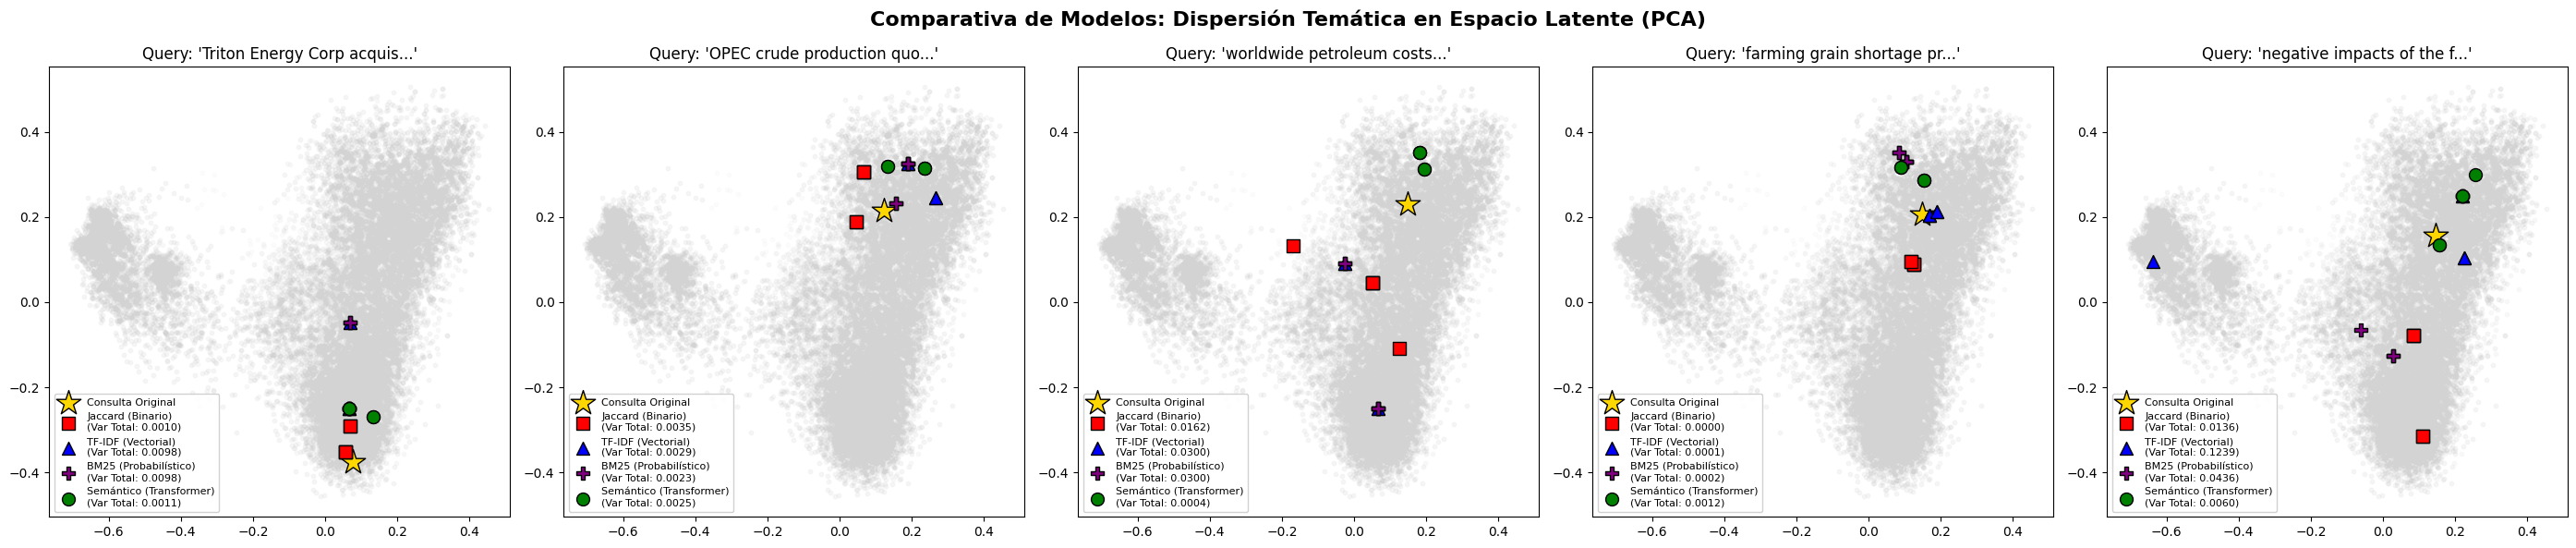

In [15]:
from sklearn.decomposition import PCA
from limpieza import limpiar_para_semantico

print("Ejecutando Análisis de Componentes Principales (PCA) sobre el hiperespacio semántico...")

# 1. REDUCCIÓN DE DIMENSIONALIDAD GLOBAL
# Comprimimos la matriz de 51,000 x 768 dimensiones a 51,000 x 2 dimensiones
pca = PCA(n_components=2)
corpus_2d = pca.fit_transform(embeddings_docs)

# Auditoría matemática de la compresión (Varianza Explicada)
varianza_explicada = pca.explained_variance_ratio_
print("PCA base generado exitosamente.")
print(f"Varianza retenida por el Eje X (Componente Principal 1): {varianza_explicada[0]*100:.2f}%")
print(f"Varianza retenida por el Eje Y (Componente Principal 2): {varianza_explicada[1]*100:.2f}%")
print(f"Varianza Total estructural conservada en el plano 2D    : {sum(varianza_explicada)*100:.2f}%\n")

# Diccionario de acceso rápido O(1) para mapear el ID del documento a su fila en la matriz PCA
docid_a_idx = {doc_id: i for i, doc_id in enumerate(idx_a_docid)}

# 2. GENERACIÓN DEL ENTORNO GRÁFICO (Subplots)
fig, axes = plt.subplots(1, 5, figsize=(28, 6))
fig.suptitle("Comparativa de Modelos: Dispersión Temática en Espacio Latente (PCA)", fontsize=16, fontweight='bold')

# 3. BUCLE DE EVALUACIÓN GEOMÉTRICA POR CONSULTA
for i, query in enumerate(consultas_auto):

    # A. Enrutamiento y Sanitización de la consulta
    consulta_semantica = limpiar_para_semantico(query)

    # B. Inferencia: Recuperación de documentos (Top 5) por cada arquitectura
    res_bm25    = bm25_search(query, indice, metadatos, idf_bm25, LONGITUD_PROMEDIO, TOTAL_DOCS, top_k=5)
    res_tfidf   = tfidf_search(query, vectorizer_tfidf, matriz_tfidf, idx_a_docid, top_k=5)
    res_jaccard = jaccard_search(query, indice, metadatos, top_k=5)
    res_sem     = semantic_search(consulta_semantica, modelo_st, indice_faiss, idx_a_docid, top_k=5)

    # C. Proyección de la consulta al mismo espacio 2D
    # Codificamos la frase, la normalizamos (crucial) y la proyectamos con el PCA entrenado
    q_emb = modelo_st.encode([consulta_semantica], normalize_embeddings=True)
    q_2d  = pca.transform(q_emb)

    ax = axes[i]

    # D. Renderizado del mapa base y el punto de interés (Consulta)
    ax.scatter(corpus_2d[:, 0], corpus_2d[:, 1], alpha=0.05, c='lightgray', s=10) # Nube de fondo
    ax.scatter(q_2d[:, 0], q_2d[:, 1], c='gold', marker='*', s=400, edgecolors='black', label="Consulta Original")

    print("-" * 80)
    print(f"EVALUACIÓN ESPACIAL {i+1}: '{query}'")
    print("-" * 80)

    datos_varianza = []

    # FUNCIÓN INTERNA: Mapeo espacial y cálculo de cohesión geométrica
    def graficar_y_calcular(resultados, color, marcador, nombre_modelo):
        # Mapeamos los IDs de los resultados a sus coordenadas en el plano 2D
        indices = [docid_a_idx[did] for did, _ in resultados if did in docid_a_idx]

        if indices:
            puntos = corpus_2d[indices]

            # Cálculo estadístico de la dispersión poblacional en los ejes ortogonales
            if len(puntos) > 1:
                var_x = np.var(puntos[:, 0])
                var_y = np.var(puntos[:, 1])
            else:
                var_x, var_y = 0.0, 0.0

            # La suma de las varianzas ortogonales representa la dispersión espacial total
            var_total = var_x + var_y

            # Registro métrico para la tabla de reporte
            datos_varianza.append({
                "Modelo": nombre_modelo,
                "Var X": f"{var_x:.4f}",
                "Var Y": f"{var_y:.4f}",
                "Var Total": f"{var_total:.4f}"
            })

            # Trazado geométrico en el gráfico
            etiqueta_leyenda = f"{nombre_modelo}\n(Var Total: {var_total:.4f})"
            ax.scatter(puntos[:, 0], puntos[:, 1], c=color, marker=marcador, s=100, label=etiqueta_leyenda, edgecolors='black')

    # Ejecución del cálculo para cada arquitectura
    graficar_y_calcular(res_jaccard, 'red', 's', 'Jaccard (Binario)')
    graficar_y_calcular(res_tfidf, 'blue', '^', 'TF-IDF (Vectorial)')
    graficar_y_calcular(res_bm25, 'purple', 'P', 'BM25 (Probabilístico)')
    graficar_y_calcular(res_sem, 'green', 'o', 'Semántico (Transformer)')

    # Presentación tabular de las métricas de varianza
    if datos_varianza:
        df_var = pd.DataFrame(datos_varianza)
        display(df_var.style.hide(axis="index"))
    print("\n")

    # Configuraciones finales del gráfico
    ax.set_title(f"Query: '{query[:25]}...'")
    ax.legend(fontsize=8, loc='best', framealpha=0.9)

# Renderizado final del bloque gráfico
plt.tight_layout()
plt.show()

### Celda 10: Evaluación Cuantitativa (MAP) y Diagnóstico Visual

#### ¿Cómo calificamos a los modelos? (Explicación sencilla)
Para saber qué modelo es mejor, necesitamos una "hoja de respuestas correctas", pero en una base de 51,000 noticias, nadie ha leído todos los artículos para decirnos cuáles son los correctos para cada búsqueda. Para resolver esto, usamos una técnica llamada **Pooling (Fondo Común)**.

Imagina que le pides a 4 expertos distintos (nuestros 4 modelos) que te den sus 3 mejores libros sobre un tema. Juntas los libros de todos, quitas los repetidos y creas una "Lista Maestra". Luego, evalúas a cada experto haciéndoles 3 preguntas:
1. **Precisión:** De los 5 resultados que me entregaste, ¿cuántos están en la Lista Maestra?
2. **Recall (Exhaustividad):** De todos los libros que existen en la Lista Maestra, ¿qué porcentaje lograste encontrar tú?
3. **AP (Precisión Promedio):** No solo importa que encuentres el documento, importa el **orden**. Si el mejor documento me lo entregas en el puesto 1, sacas un 100%. Si me lo entregas en el puesto 5 (después de hacerme leer basura), tu calificación baja drásticamente.

El **MAP (Mean Average Precision)** es simplemente el promedio final de las calificaciones de AP de un modelo tras pasar por todas las pistas de prueba.

#### Explicación Técnica y Arquitectónica
Esta sección implementa un entorno de evaluación no supervisado basado en el estándar de TREC (Text REtrieval Conference):
* **Estrategia de Pooling Estratificado:** Al unir el Top-N de *cada* modelo, construimos un "Gold Standard" dinámico y equitativo. Esto es crucial porque si solo usáramos los resultados de BM25 y TF-IDF para crear la verdad base, crearíamos una "cámara de eco" léxica que penalizaría injustamente al Modelo Semántico cuando este encuentra documentos contextualmente válidos pero sin coincidencia de palabras.
* **Matriz de Calor (Heatmap):** Permite un diagnóstico visual inmediato. Las filas son las consultas y las columnas son los modelos. Al observar la matriz, se evidencia empíricamente la "Maldición del Vocabulario" (Vocabulary Mismatch Problem): los modelos léxicos obtienen un AP cercano a 0 en las consultas con sinónimos, mientras que el modelo neuronal mantiene un rendimiento estable frente a la abstracción.

TABLA 1: RANKING GLOBAL DE ARQUITECTURAS (MAP@25)


Modelo,MAP (Mean Average Precision)
TF-IDF,0.5912
BM25,0.5361
Jaccard,0.4534
Semántico,0.4331



TABLA 2: DESGLOSE DE MÉTRICAS POR CONSULTA (@25)


Consulta,Modelo,Relevantes (Pool),Precision@25,Recall@25,AP@25
Triton Energy Corp acquisition,BM25,26,0.6000,0.5769,0.5708
Triton Energy Corp acquisition,TF-IDF,26,0.6000,0.5769,0.5856
Triton Energy Corp acquisition,Jaccard,26,0.4800,0.4615,0.4600
Triton Energy Corp acquisition,Semántico,26,0.4000,0.3846,0.4000
OPEC crude production quota,BM25,33,0.7600,0.5758,0.6685
OPEC crude production quota,TF-IDF,33,0.6400,0.4848,0.6356
OPEC crude production quota,Jaccard,33,0.4000,0.3030,0.4000
OPEC crude production quota,Semántico,33,0.5200,0.3939,0.5028
worldwide petroleum costs decrease,BM25,31,0.6400,0.5161,0.5889
worldwide petroleum costs decrease,TF-IDF,31,0.5600,0.4516,0.5289



DIAGNÓSTICO VISUAL: MATRIZ DE CALOR DE RENDIMIENTO (AP@25)


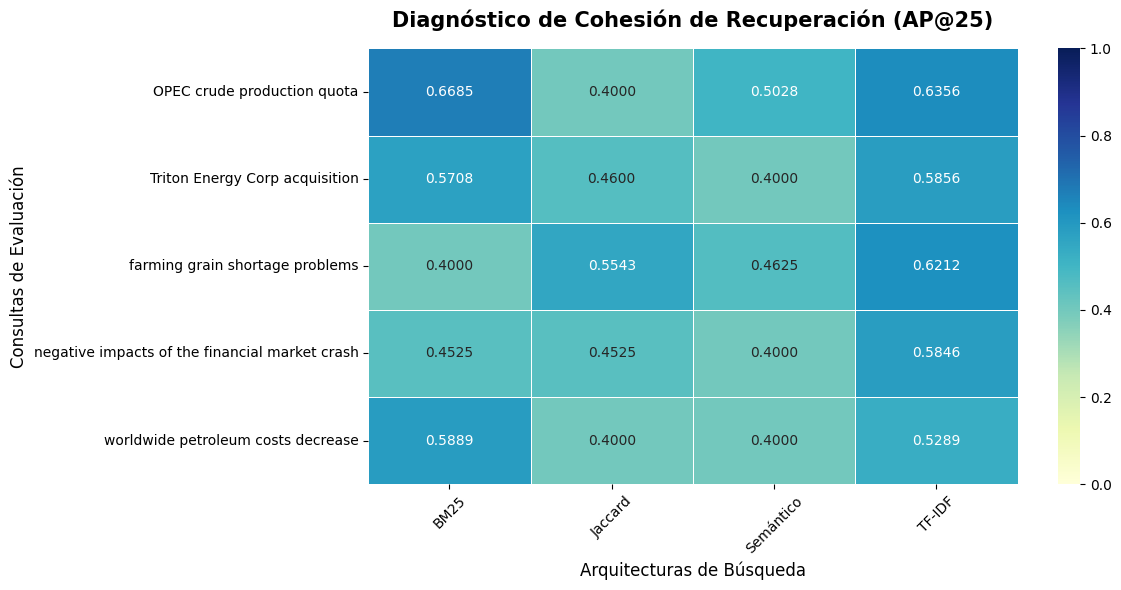

In [16]:
# EVALUACIÓN CUANTITATIVA Y MATRIZ DE CALOR
# Construcción de Ground Truth mediante Pooling y cálculo de MAP@K
import seaborn as sns

# 1. HIPERPARÁMETROS DE EVALUACIÓN
K_EVALUACION = 25  # Profundidad de evaluación (Top 5 documentos)
N_POOLING    = 10  # Aporte estricto por modelo para la "Lista Maestra" (Evita sesgos)

# 2. DEFINICIÓN ESTRICTA DE MÉTRICAS (Information Retrieval)
def precision_at_k(retrieved: list, relevant: list, k: int = K_EVALUACION) -> float:
    """Mide la pureza de los resultados recuperados (Cuántos son relevantes)."""
    if not relevant or not retrieved:
        return 0.0
    retrieved_k = retrieved[:k]
    relevant_retrieved = set(retrieved_k).intersection(set(relevant))
    return len(relevant_retrieved) / k

def recall_at_k(retrieved: list, relevant: list, k: int = K_EVALUACION) -> float:
    """Mide la exhaustividad (Cuántos relevantes del total logramos capturar)."""
    if not relevant or not retrieved:
        return 0.0
    retrieved_k = retrieved[:k]
    relevant_retrieved = set(retrieved_k).intersection(set(relevant))
    return len(relevant_retrieved) / len(relevant)

def average_precision_at_k(retrieved: list, relevant: list, k: int = K_EVALUACION) -> float:
    """Penaliza el orden de aparición. Un hit en rango 1 vale más que en rango 5."""
    if not relevant or not retrieved:
        return 0.0
    ap = 0.0
    hits = 0
    for i, doc_id in enumerate(retrieved[:k]):
        if doc_id in relevant:
            hits += 1
            ap += hits / (i + 1.0) # Se divide por la posición (índice + 1)

    divisor = min(len(relevant), k)
    return ap / divisor if divisor > 0 else 0.0

# 3. CONSTRUCCIÓN DE LA VERDAD BASE (Pooling Estratificado)
qrels_pooling = {}
resultados_por_query = {}

for query in consultas_auto:
    # Acondicionamiento paralelo
    consulta_semantica = limpiar_para_semantico(query)

    # Inferencia profunda para asegurar la extracción del Top K
    res_bm25_full    = [x[0] for x in bm25_search(query, indice, metadatos, idf_bm25, LONGITUD_PROMEDIO, TOTAL_DOCS, top_k=K_EVALUACION)]
    res_tfidf_full   = [x[0] for x in tfidf_search(query, vectorizer_tfidf, matriz_tfidf, idx_a_docid, top_k=K_EVALUACION)]
    res_jaccard_full = [x[0] for x in jaccard_search(query, indice, metadatos, top_k=K_EVALUACION)]
    res_sem_full     = [x[0] for x in semantic_search(consulta_semantica, modelo_st, indice_faiss, idx_a_docid, top_k=K_EVALUACION)]

    # Almacenamiento en caché de los resultados Top K para evaluación posterior
    resultados_por_query[query] = {
        "BM25"     : res_bm25_full,
        "TF-IDF"   : res_tfidf_full,
        "Jaccard"  : res_jaccard_full,
        "Semántico": res_sem_full
    }

    # Creación del "Gold Standard": Fusión de los N mejores documentos sin duplicados.
    # Al incluir al modelo semántico, prevenimos el sesgo de la "cámara de eco léxica".
    docs_relevantes = set(
        res_bm25_full[:N_POOLING] +
        res_tfidf_full[:N_POOLING] +
        res_jaccard_full[:N_POOLING] +
        res_sem_full[:N_POOLING]
    )

    qrels_pooling[query] = list(docs_relevantes)

# 4. CÁLCULO ITERATIVO DE MÉTRICAS (P, R, AP, MAP)
datos_evaluacion = []
map_scores = {"BM25": [], "TF-IDF": [], "Jaccard": [], "Semántico": []}

for query in consultas_auto:
    relevantes = qrels_pooling[query]

    for modelo_nombre, recuperados_top5 in resultados_por_query[query].items():
        p_k = precision_at_k(recuperados_top5, relevantes, k=K_EVALUACION)
        r_k = recall_at_k(recuperados_top5, relevantes, k=K_EVALUACION)
        ap  = average_precision_at_k(recuperados_top5, relevantes, k=K_EVALUACION)

        map_scores[modelo_nombre].append(ap)

        datos_evaluacion.append({
            "Consulta": query,
            "Modelo": modelo_nombre,
            "Relevantes (Pool)": len(relevantes),
            f"Precision@{K_EVALUACION}": f"{p_k:.4f}",
            f"Recall@{K_EVALUACION}": f"{r_k:.4f}",
            f"AP@{K_EVALUACION}": f"{ap:.4f}"
        })

df_evaluacion = pd.DataFrame(datos_evaluacion)

# Consolidación Matemática Global (Mean Average Precision)
datos_map = []
for modelo_nombre, lista_ap in map_scores.items():
    datos_map.append({
        "Modelo": modelo_nombre,
        "MAP (Mean Average Precision)": f"{np.mean(lista_ap):.4f}"
    })
df_map = pd.DataFrame(datos_map).sort_values(by="MAP (Mean Average Precision)", ascending=False)

# 5. RENDERIZADO DE RESULTADOS (Tablas y Matriz)
print("="*80)
print(f"TABLA 1: RANKING GLOBAL DE ARQUITECTURAS (MAP@{K_EVALUACION})")
print("="*80)
display(df_map.style.hide(axis="index"))

print("\n" + "="*80)
print(f"TABLA 2: DESGLOSE DE MÉTRICAS POR CONSULTA (@{K_EVALUACION})")
print("="*80)
display(df_evaluacion.style.hide(axis="index"))

print("\n" + "="*80)
print(f"DIAGNÓSTICO VISUAL: MATRIZ DE CALOR DE RENDIMIENTO (AP@{K_EVALUACION})")
print("="*80)

# Pivoteo estructural para graficar: Filas (Consultas) x Columnas (Modelos)
df_heatmap = df_evaluacion.pivot(index="Consulta", columns="Modelo", values=f"AP@{K_EVALUACION}").astype(float)

plt.figure(figsize=(12, 6))
sns.heatmap(
    df_heatmap,
    annot=True,          # Inyectar el valor numérico en cada celda
    cmap="YlGnBu",       # Gradiente de intensidad (Amarillo a Azul oscuro)
    fmt=".4f",           # Rigor de 4 decimales
    linewidths=.5,       # Malla de separación
    vmin=0, vmax=1       # Rango absoluto de métrica probabilística
)

plt.title(f"Diagnóstico de Cohesión de Recuperación (AP@{K_EVALUACION})", fontsize=15, pad=15, fontweight='bold')
plt.ylabel("Consultas de Evaluación", fontsize=12)
plt.xlabel("Arquitecturas de Búsqueda", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()